<img style="float: left; margin: 30px 15px 15px 15px;" src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="400" height="600" /> 
    
    
## <font color='navy'> PAP Optimización de Programas de Inversión
    
### <font color='navy'> Actividad: Hierarchical Risk Parity

Profesor: Sean Nicolás González Vázquez.

### **Objetivo**: Aplicar los conceptos de HRP vistos en clase, implementando el método para obtener los pesos de una cartera de inversión. 

>  **<font color='navy'>  Implementación de HRP Manual** (80 puntos)

Aplicar los tres pasos del HRP:

+ Hierarchical Clustering Tree

+ Quasi-Diagonalization

+ HRP Algorithm 

Y obtener las ponderaciones eficientes utilizando el algoritmo para el portafolio de inversión dado. 

A continuación se desglosa lo que se espera que se entrege en cada punto:

+ **Hierarchical Clustering Tree**

En este punto, se espera que se entregue el mapa de calor con las correlaciones de la cartera planteada, además, se aplicará clustering jerárquico sobre los rendimientos de esta, para encontrar el dendograma. 

+ **Quasi-Diagonalization**

Con el Árbol Jerárquico obtenido en la parte anterior, se espera, haciendo uso de las hojas obtenidas, que se ordenen los rendimientos para obtener la matriz de correlación seriada matricialmente o quasi-diagonalizada. Graficar el mapa de calor de esta.

+ **HRP Algorithm**

Con los dos puntos anteriores y las formúlas vistas en clase, se espera que se complete la clase `HierarchicalRiskParity` dada en la siguiente sección, esta clase, recibirá solamente los rendimientos del portafolio sin quasi-diagonalizar (sin tener el orden de la parte anterior) y la lista con el orden de las hojas dadas por el clustering jerárquico. A posteriori, se completarán los métodos de la clase para que al aplicar el método `HRP` de la clase generada sobre un portafolio de acciones, se obtengan las ponderaciones eficientes. 

Después de obtener los pesos, se deberán de graficar en una gráfica de barras, se deben de observar los tickers en el eje x. 


**Ojo:** A continuación se muestra una estructura del código que debes utilizar, el método de HRP debe de ser implementado en clases de manera obligatoria. Tarea sin interpretación de resultados no la calificaré.


### Raúl Oviedo Magaña

### José Luis Almendarez Gonzáles

In [1]:
import numpy as np
import pandas as pd


import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list

In [2]:
# Lista de tickers
tickers=["IEF", "BND", "LQD", "TIP", "XLU", "TLT", "XLB", "DIA",
         "EWJ", "SPY", "XLK", "XLE", "EWQ", "XLF"]

Los activos pertenecen a los siguientes sectores:

**Renta Fija / Bonos**

IEF: Bonos del tesoro EE.UU 7-10 años

TLT: Bonos del tesoro a largo plazo +20 años

BND: Mercado total de bonos EE.UU

LQD: Bonos corporativos de grado de inversión

TIP: Bonos del tesoro protegidos contra inflación

**Renta variable - Indices**

SPY: Las 500 mayores empresas de EE.UU

DIA: Las 30 grandes industrialles del Dow Jones

**Renta variable - Sectores específicos**

XLK: Tecnología

XLF: Sector financiero / bancos

XLE: Energía / Petróleo

XLU: Servicios públicos (defensivo)

XLB: Materiales / Materias primas

**Renta variable - Internacional**

EWJ: Japón
EWQ: Francia

In [3]:
# descargar precios
prices = yf.download(tickers, start="2010-01-01", end="2026-06-05")["Close"].dropna()
prices.tail()

[*********************100%***********************]  14 of 14 completed


Ticker,BND,DIA,EWJ,EWQ,IEF,LQD,SPY,TIP,TLT,XLB,XLE,XLF,XLK,XLU
Date,,,,,,,,,,,,,,
2026-05-29,73.212997,510.779999,92.959999,45.970001,94.333000,108.947006,756.479980,109.931999,85.424004,51.150002,56.290001,51.580002,191.020004,44.419998
2026-06-01,73.180000,511.440002,92.930000,45.820000,94.169998,108.930000,758.539978,109.980003,85.470001,50.919998,57.299999,51.430000,195.759995,43.099998
2026-06-02,73.199997,514.049988,93.580002,46.080002,94.239998,108.919998,759.570007,109.970001,85.650002,51.520000,57.959999,51.459999,198.210007,43.900002
2026-06-03,73.059998,508.260010,93.940002,45.529999,94.000000,108.620003,754.239990,109.769997,85.309998,51.630001,58.709999,50.869999,196.229996,43.709999
2026-06-04,73.160004,516.700012,94.129997,46.290001,94.120003,108.849998,757.090027,109.779999,85.500000,51.619999,58.750000,52.189999,193.169998,43.939999


In [4]:
# rendimientos
returns = np.log(prices / prices.shift(1)).dropna()
returns.tail()

Ticker,BND,DIA,EWJ,EWQ,IEF,LQD,SPY,TIP,TLT,XLB,XLE,XLF,XLK,XLU
Date,,,,,,,,,,,,,,
2026-05-29,0.000545,0.007329,0.002801,-0.000652,0.001163,0.000915,0.002488,0.000270,0.000233,-0.004097,-0.011657,0.006028,0.022072,-0.004717
2026-06-01,-0.000451,0.001291,-0.000323,-0.003268,-0.001729,-0.000156,0.002719,0.000437,0.000538,-0.004507,0.017784,-0.002912,0.024511,-0.030167
2026-06-02,0.000273,0.005090,0.006970,0.005658,0.000743,-0.000092,0.001357,-0.000091,0.002104,0.011714,0.011452,0.000583,0.012438,0.018391
2026-06-03,-0.001914,-0.011327,0.003840,-0.012008,-0.002550,-0.002758,-0.007042,-0.001820,-0.003978,0.002133,0.012857,-0.011531,-0.010040,-0.004337
2026-06-04,0.001368,0.016469,0.002020,0.016555,0.001276,0.002115,0.003772,0.000091,0.002225,-0.000194,0.000681,0.025618,-0.015717,0.005248


Text(0.5, 1.0, 'Matriz de Correlación de Rendimientos')

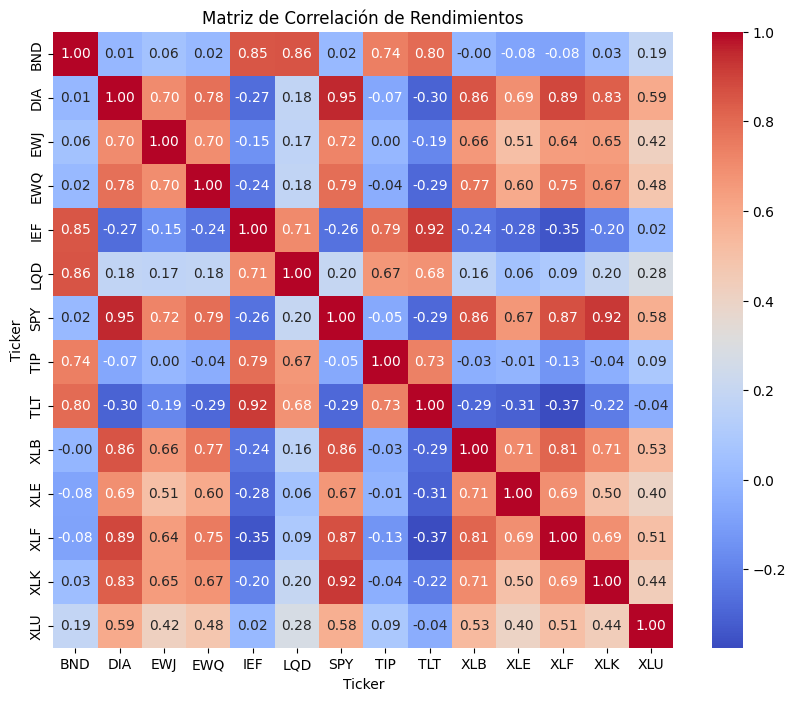

In [5]:
# mapa de calor de matriz correlacion
plt.figure(figsize=(10, 8))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación de Rendimientos")

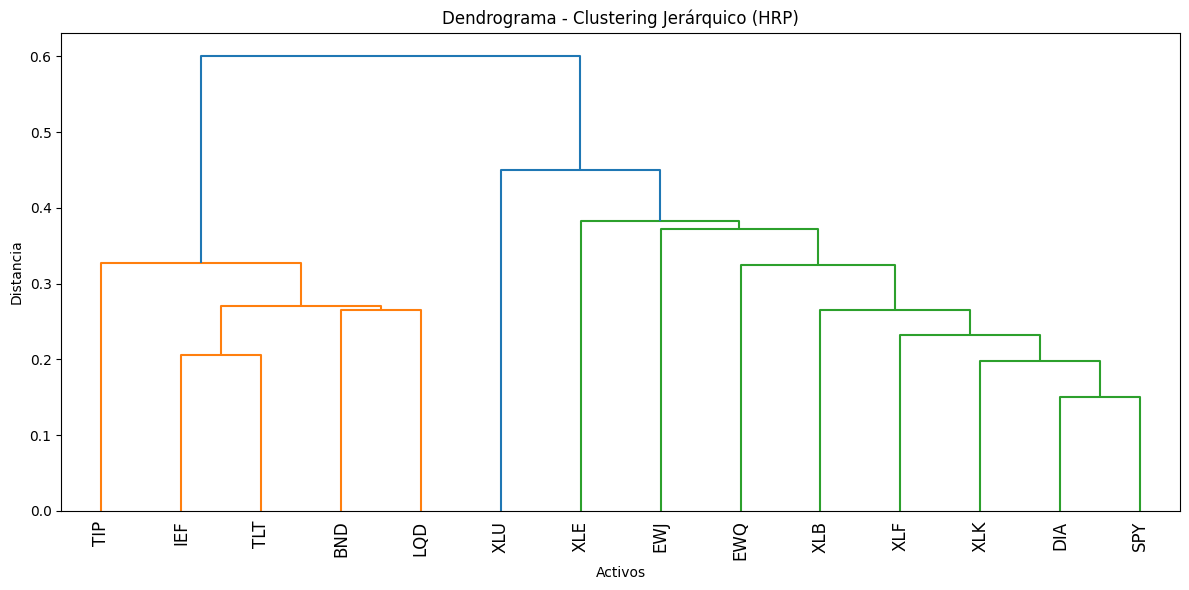

In [ ]:
# aplicar clustering jerarquico, dibujar dendograma

corr = returns.corr()

# Convertir la correlación en una matriz de distancia de correlación
dist = np.sqrt((1 - corr) / 2)

# linkage necesita la distancia en formato condensado
# solamente el triangulo superior sin la diagonal, ni repetidos
n = dist.shape[0]
condensed = dist.values[np.triu_indices(n, k=1)]

# Linkage usando el método single (vecino más cercano)
link = linkage(condensed, method="single")

# Dibujar el dendrograma
plt.figure(figsize=(12, 6))
dendrogram(link, labels=corr.columns.tolist(), leaf_rotation=90)
plt.title("Dendrograma - Clustering Jerárquico (HRP)")
plt.xlabel("Activos")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()

El dendograma confirma 2 grandes familias de activo claramente separadas. La linea azul divide el unvierso de activos en 2 ramas principales con una distancia de 0.6, lo que significa que los 2 grupos son muy poco correlacionados entre sí y se comportan de manera opuesta

**Los 2 grupos son:**

Renta Fija: TIP, IEF, TLT, BND, LQD

Renta variable: XLU, XLE, EWJ, EWQ, XLB, XLF, XLK, DIA, SPY

**Dentro de los activos de renta fija** podemos observar que IEF + TLT tienen una distancia muy pequeña de 0.2, porque ambos son Treasuries puros de mediano y largo plazo muy parecidos.

**Observando la parte de renta variable** podemos ver que los activos que tienen la menor distancia de todos son DIA + SPY, que son el SP500 y Dow, son casi el mismo activo porque tienen una altisima correlación

Los internacionales como EWJ y EWQ (Japón y Francia), tienen una distancia un poco mas lejos de 0.32-0.38 aprox.

El clustering captó perfectamente la lógica económica del portafolio sin necesidad de especificar a que sector pertenecia cada activo, agrupó por similitud de comportamiento

In [7]:
# obtener lista con orden de hojas del dendograma

# leaves_list devuelve los índices de los activos en el orden en que aparecen
# las hojas del dendrograma (de izquierda a derecha)
quasi_index = leaves_list(link)
print("Orden de las hojas (índices):", quasi_index)

sorted_tickers = corr.columns[quasi_index].tolist()
print("Orden de las hojas (tickers):", sorted_tickers)

Orden de las hojas (índices): [ 7  4  8  0  5 13 10  2  3  9 11 12  1  6]
Orden de las hojas (tickers): ['TIP', 'IEF', 'TLT', 'BND', 'LQD', 'XLU', 'XLE', 'EWJ', 'EWQ', 'XLB', 'XLF', 'XLK', 'DIA', 'SPY']


El algoritmo colocó los activos en fila según su parecido, exactamente como aparecen de izquierda a derecha en el dendograma.

Primero todos los bonos juntos y después todas las acciones juntas

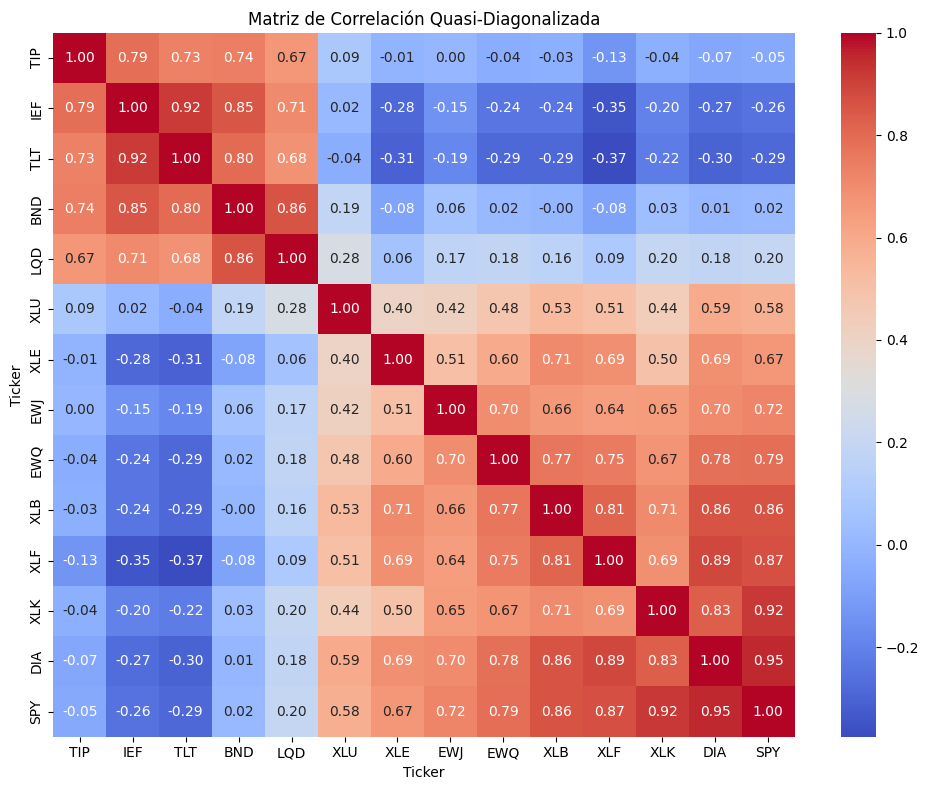

In [8]:
# quasi-diagonalización de rendtos, plotear mapa de calor de correlaciones

# Reordenar los rendimientos según el orden de las hojas del dendrograma
returns_quasi = returns.iloc[:, quasi_index]

# Matriz de correlación quasi-diagonalizada 
corr_quasi = returns_quasi.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_quasi, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación Quasi-Diagonalizada")
plt.tight_layout()
plt.show()

Observando el grafico podemos ver que se encuentran 2 bloques en rojo intenso, esto se debe a que tienen correlación muy alta, practicamente se mueven juntos. 

En la esquina superior izquierda tenemos los bonos

En la esquina inferior derecha tenemos las acciones

Las esquinas azules son las correlaciones entre bonos y acciones, como se encuentran cerca de 0 y negativas son la clave de la diversificación.

Cuando las acciones caen, los bonos normalmente se sostienen o suben, de esta manera funcionan como contrapesos naturales.

In [10]:
# Aplicacion de Algoritmo HRP
class HierarchicalRiskParity:
    
    def __init__(self, rends, quasi_index):
        
        self.names=rends.columns
        self.cov=rends.cov() 
        self.names=rends.iloc[:, quasi_index].columns
        self.indexes=quasi_index
        
    # metodo para obtener la variación de los clusters
    def cluster_variation(self, items):
        
        # Obtener primero pesos temporales del cluster con funcion de cov inversa
        
        # Obtener varianza temporal del cluster
        
        return ... # retornar varianza del cluster
    
    
    @staticmethod # biseccion recursiva
    def bisection(items): 
        new_items = [i[int(j):int(k)] for i in items for j, k in
                     ((0, len(i) / 2), (len(i) / 2, len(i))) if len(i) > 1]
        return new_items 
    
    # funcion para la obtencion de pesos por HRP
    def HRP(self):
        
        # Inicializar pesos
        
        # Inicializar clusters con indices dados por cluster 
        
        # Mientras sigamos teniendo clusters...
        while len(clusters)>0:
            # Aplicamos biseccion recursiva 
            clusters = self.bisection(clusters)
            
            # Para cada cluster de la biseccion recursiva spliteando en dos:
            for i in range(0, len(clusters), 2):
                
                ...
                
                # Obtener indice i e i+1 de clusters
                
                # Calcular varianza de i e i+1 cluster, utilizar cluster_variation
                
                # Calcular alpha o factor de ajuste de los pesos
                
                # Ajustar pesos con alpha
                
                
        return ... # retornar pesos
        

In [ ]:
# aplicar clase creada en nuestro portafolio

In [ ]:
# graficar pesos

> **<font color='navy'> Implementación de HRP con PyPortopt** (20 puntos)
    
Instalar la librería `PyPortfolioOpt` de Python, una librería que ayuda a optimizar cuantitativamente portafolios de inversión. 
    
Esta librería se puede instalar de la siguiente manera:
    
`pip install PyPortfolioOpt`
    
    
Buscar en la documentación de la librería, el método `HRP_opt` que utiliza Hierarchical Risk Parity para obtener las ponderaciones eficientes de un portafolio de inversión.
    
Después de obtener las ponderaciones, graficarlas, notesé que los resultados obtenidos deben de dar lo mismo que los resultados obtenidos en la sección anterior, si no sucede esto, tu código es érroneo.

Pesos HRP (PyPortfolioOpt):
OrderedDict({'BND': 0.3438, 'DIA': 0.01412, 'EWJ': 0.02508, 'EWQ': 0.00864, 'IEF': 0.11025, 'LQD': 0.13727, 'SPY': 0.01309, 'TIP': 0.24957, 'TLT': 0.02136, 'XLB': 0.01057, 'XLE': 0.01383, 'XLF': 0.00929, 'XLK': 0.00934, 'XLU': 0.03377})


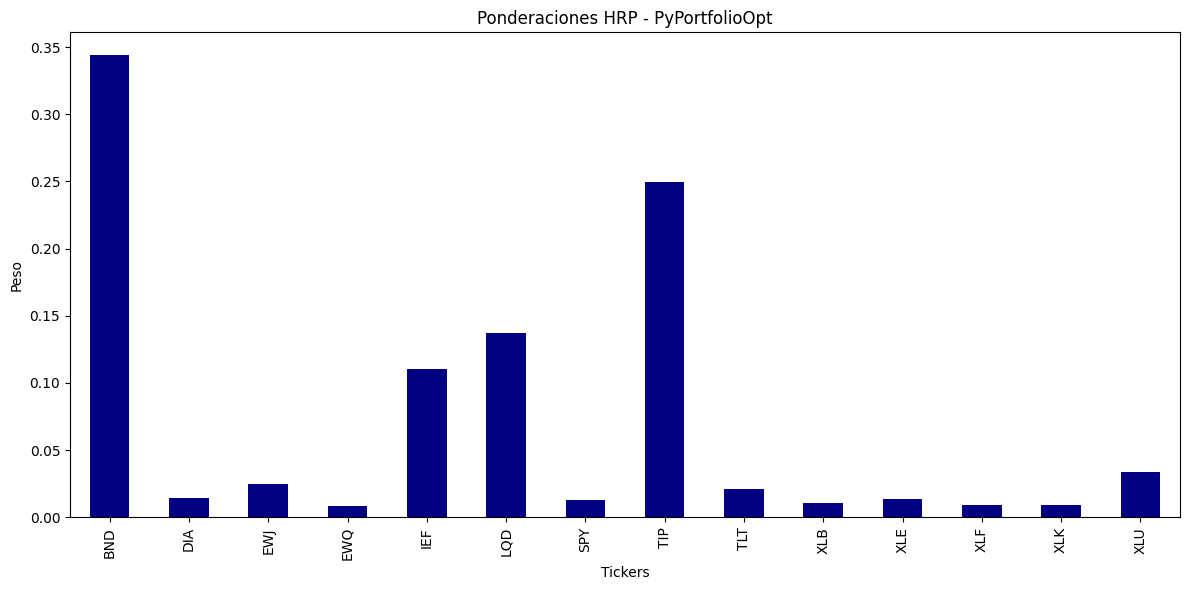

In [ ]:
from pypfopt import HRPOpt

# HRPOpt recibe los rendimientos del portafolio
hrp = HRPOpt(returns)

# optimize() aplica Hierarchical Risk Parity y devuelve las ponderaciones eficientes.
# Usa 'single' por defecto
weights_pypfopt = hrp.optimize()
weights_pypfopt = hrp.clean_weights()
print("Pesos HRP (PyPortfolioOpt):")
print(weights_pypfopt)

# Graficar ponderaciones
pesos = pd.Series(weights_pypfopt)
plt.figure(figsize=(12, 6))
pesos.plot(kind="bar", color="navy")
plt.title("Ponderaciones HRP - PyPortfolioOpt")
plt.xlabel("Tickers")
plt.ylabel("Peso")
plt.tight_layout()
plt.show()

Los pesos son:

**Bonos**
BND = 34.4%
TIP = 25.0%
LQD = 13.7%
IEF = 11.0%
TLT = 2.1%
Total = 86%

**Acciones**
XLU = 3.4%
EWJ = 2.5%
DIA, XLE, SPY.. = Reciben aprox 1% cada una
Total = 14%

Los bonos son tranquilos tienen poca volatilidad reciben la mayor parte mientras que las acciones que tienen mucha volatilidad reciben poco para no desestabilizar la cartera